<a href="https://colab.research.google.com/github/Poojaselvaraj1512/Inventory-optimisation-using-sales-data-/blob/main/Inventory_Optimisation_Using_sales_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving GSTSummary 2.xlsx to GSTSummary 2.xlsx
Saving PurchaseRegister.xlsx to PurchaseRegister.xlsx
Saving SalesRegister.xlsx to SalesRegister.xlsx
Saving StockStatus.xlsx to StockStatus.xlsx


In [ ]:
# Cell 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Cell 2: Define Headers and Data Loader
HEADERS = [
    "Date", "Bill No", "Account", "GSTIN", "Type",
    "Total Amount", "Purchase Amount", "Taxable Amount",
    "IGST", "CGST", "SGST", "Other Amount"
]

def load_clean_data(file_path, sheet_names=["Sheet2", "Sheet2"]):
    all_data = pd.DataFrame()
    for sheet in sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet, skiprows=5, names=HEADERS)
        df = df[['Date', 'Total Amount']]
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df['Total Amount'] = pd.to_numeric(df['Total Amount'], errors='coerce')
        df = df.dropna()
        all_data = pd.concat([all_data, df])
    monthly = all_data.set_index('Date').resample('M').sum()
    return monthly

In [ ]:
# Upload sales and purchase files
uploaded = files.upload()

# Load the uploaded files, assuming the header is in the first row (index 0)
sales_df = pd.read_excel("SalesRegister.xlsx", header=0)


# Show first 5 rows
display(sales_df.head(5))

Saving SalesRegister.xlsx to SalesRegister (1).xlsx


,Date,Vch/Bill No,Account,TIN/GSTIN No.,Type,Total Amount,Sale Amount,Taxable Amt.,IGST,CGST,SGST,Other Amount.
0,2024-04-01 00:00:00,1,HARINI - 5466,NaN,L/GST-TaxIncl.,2920.0,2497.26,2497.26,0.0,211.37,211.37,0.0
1,2024-04-01 00:00:00,B-5,.DHANRAJ- 1420,NaN,L/GST-TaxIncl.,9520.0,9066.64,9066.64,0.0,226.68,226.68,0.0
2,2024-04-01 00:00:00,F-1,NISHANTH - 5461,NaN,L/GST-TaxIncl.,27780.0,26302.34,26302.34,0.0,738.83,738.83,0.0
3,2024-04-01 00:00:00,F-2,RAMESHKUMAR - 9830,NaN,L/GST-TaxIncl.,23900.0,22761.90,22761.90,0.0,569.05,569.05,0.0
4,2024-04-01 00:00:00,P-1,ALLIMUTHU - 4255,NaN,L/GST-TaxIncl.,4388.0,3718.62,3718.62,0.0,334.69,334.69,0.0


In [ ]:
uploaded = files.upload()
# Load the uploaded files, assuming the header is in the first row (index 0)
purchase_df = pd.read_excel("PurchaseRegister.xlsx", header=0)
display(purchase_df.head(5))

Saving PurchaseRegister.xlsx to PurchaseRegister (1).xlsx


,Date,Vch/Bill No,Account,TIN/GSTIN No.,Type,Total Amount,Purc. Amount,Taxable Amt.,IGST,CGST,SGST,Other Amount.
0,2024-04-01 00:00:00,P/4,A.P.AGRI SOLLUTIONS,33AKMPK0174D1ZI,L/GST-18%,10301.0,8730.00,8730.00,0.0,785.70,785.70,-0.40
1,2024-04-01 00:00:00,P/8,PREMKRISHNA ASSOCIATES,33BHMPK6821R1ZP,L/GST-18%,27270.0,23109.28,23109.28,0.0,2079.84,2079.84,1.04
2,2024-04-01 00:00:00,F/0003,EVERGREEN AGRO TRADERS,33AABFE0125H1Z6,L/GST-12%,7504.0,6700.00,6700.00,0.0,402.00,402.00,0.00
3,2024-04-01 00:00:00,P/0051,SATHYA AGRI INPUTS,33ABLFS6152P1ZK,L/GST-18%,10927.0,9260.22,9260.22,0.0,833.42,833.42,-0.06
4,2024-04-02 00:00:00,P/35,COVAI IMPEX,33AAJFC9013C1ZX,L/GST-18%,12000.0,10169.52,10169.52,0.0,915.26,915.26,-0.04


In [ ]:
df_raw = pd.read_excel("SalesRegister.xlsx", header=None)

# Show first 10 rows and 10 columns
print(df_raw.iloc[:10, :10])

                     0            1                    2              3  \
0                 Date  Vch/Bill No              Account  TIN/GSTIN No.   
1  2024-04-01 00:00:00            1       HARINI -  5466            NaN   
2  2024-04-01 00:00:00          B-5     .DHANRAJ-   1420            NaN   
3  2024-04-01 00:00:00          F-1    NISHANTH  -  5461            NaN   
4  2024-04-01 00:00:00          F-2   RAMESHKUMAR - 9830            NaN   
5  2024-04-01 00:00:00          P-1     ALLIMUTHU - 4255            NaN   
6  2024-04-02 00:00:00          B-6    KARANKUMAR - 6670            NaN   
7  2024-04-02 00:00:00          F-3      PONNUSAMY- 4741            NaN   
8  2024-04-02 00:00:00          P-2       VIGNESH - 7139            NaN   
9  2024-04-03 00:00:00          F-4  RANGANATHAN -  3797            NaN   

                4             5            6             7     8       9  
0            Type  Total Amount  Sale Amount  Taxable Amt.  IGST    CGST  
1  L/GST-TaxIncl.       

In [ ]:


# Try reading with the first row as header
df = pd.read_excel("SalesRegister.xlsx", header=0)

# If columns look like Unnamed, try row 1 or 2 as header
df = pd.read_excel("SalesRegister.xlsx", header=0)
df = pd.read_excel("SalesRegister.xlsx", header=1)  # header in 2nd row
df = pd.read_excel("SalesRegister.xlsx", header=2)  # header in 3rd row
df = pd.read_excel("SalesRegister.xlsx", header=3)
df = pd.read_excel("SalesRegister.xlsx", header=4)
df = pd.read_excel("SalesRegister.xlsx", header=5)
df = pd.read_excel("SalesRegister.xlsx", header=6)
df = pd.read_excel("SalesRegister.xlsx", header=7)
df = pd.read_excel("SalesRegister.xlsx", header=8)
df = pd.read_excel("SalesRegister.xlsx", header=9)
df = pd.read_excel("SalesRegister.xlsx", header=10)



In [ ]:
df=pd.read_excel("SalesRegister.xlsx")
df.head()

,Date,Vch/Bill No,Account,TIN/GSTIN No.,Type,Total Amount,Sale Amount,Taxable Amt.,IGST,CGST,SGST,Other Amount.
0,2024-04-01 00:00:00,1,HARINI - 5466,NaN,L/GST-TaxIncl.,2920.0,2497.26,2497.26,0.0,211.37,211.37,0.0
1,2024-04-01 00:00:00,B-5,.DHANRAJ- 1420,NaN,L/GST-TaxIncl.,9520.0,9066.64,9066.64,0.0,226.68,226.68,0.0
2,2024-04-01 00:00:00,F-1,NISHANTH - 5461,NaN,L/GST-TaxIncl.,27780.0,26302.34,26302.34,0.0,738.83,738.83,0.0
3,2024-04-01 00:00:00,F-2,RAMESHKUMAR - 9830,NaN,L/GST-TaxIncl.,23900.0,22761.90,22761.90,0.0,569.05,569.05,0.0
4,2024-04-01 00:00:00,P-1,ALLIMUTHU - 4255,NaN,L/GST-TaxIncl.,4388.0,3718.62,3718.62,0.0,334.69,334.69,0.0


In [ ]:
# Ensure "Date" is converted properly and cleaned for purchase_df
purchase_df["Date"] = pd.to_datetime(purchase_df["Date"], errors="coerce")

# Drop rows where Date is NaT (invalid/missing dates) or where 'Account' contains 'Total'
purchase_df = purchase_df.dropna(subset=["Date"])
purchase_df = purchase_df[~purchase_df['Account'].astype(str).str.contains('Total', na=False)]

# Convert numeric columns safely for purchase_df
numeric_cols_purchase = ["Total Amount", "IGST", "CGST", "SGST", "Other Amount."]
for col in numeric_cols_purchase:
    purchase_df[col] = pd.to_numeric(purchase_df[col], errors="coerce")

# Now set Date as index for purchase_df
purchase_df = purchase_df.set_index("Date").sort_index()

# Ensure "Date" is converted properly and cleaned for sales_df
sales_df["Date"] = pd.to_datetime(sales_df["Date"], errors="coerce")

# Drop rows where Date is NaT (invalid/missing dates) or where 'Account' contains 'Total'
sales_df = sales_df.dropna(subset=["Date"])
sales_df = sales_df[~sales_df['Account'].astype(str).str.contains('Total', na=False)]

# Convert numeric columns safely for sales_df
numeric_cols_sales = ["Total Amount", "IGST", "CGST", "SGST", "Other Amount."]
for col in numeric_cols_sales:
    sales_df[col] = pd.to_numeric(sales_df[col], errors="coerce")

# Now set Date as index for sales_df
sales_df = sales_df.set_index("Date").sort_index()


# Merge sales and purchase dataframes on the Date index
merged_df = sales_df.merge(purchase_df, left_index=True, right_index=True, suffixes=('_sales', '_purchase'))

# Display the merged dataframe
display(merged_df.head(5))

,Vch/Bill No_sales,Account_sales,TIN/GSTIN No._sales,Type_sales,Total Amount_sales,Sale Amount,Taxable Amt._sales,IGST_sales,CGST_sales,SGST_sales,...,Account_purchase,TIN/GSTIN No._purchase,Type_purchase,Total Amount_purchase,Purc. Amount,Taxable Amt._purchase,IGST_purchase,CGST_purchase,SGST_purchase,Other Amount._purchase
Date,,,,,,,,,,,,,,,,,,,,,
2024-04-01,1,HARINI - 5466,NaN,L/GST-TaxIncl.,2920.0,2497.26,2497.26,0.0,211.37,211.37,...,A.P.AGRI SOLLUTIONS,33AKMPK0174D1ZI,L/GST-18%,10301.0,8730.00,8730.00,0.0,785.70,785.70,-0.40
2024-04-01,1,HARINI - 5466,NaN,L/GST-TaxIncl.,2920.0,2497.26,2497.26,0.0,211.37,211.37,...,PREMKRISHNA ASSOCIATES,33BHMPK6821R1ZP,L/GST-18%,27270.0,23109.28,23109.28,0.0,2079.84,2079.84,1.04
2024-04-01,1,HARINI - 5466,NaN,L/GST-TaxIncl.,2920.0,2497.26,2497.26,0.0,211.37,211.37,...,EVERGREEN AGRO TRADERS,33AABFE0125H1Z6,L/GST-12%,7504.0,6700.00,6700.00,0.0,402.00,402.00,0.00
2024-04-01,1,HARINI - 5466,NaN,L/GST-TaxIncl.,2920.0,2497.26,2497.26,0.0,211.37,211.37,...,SATHYA AGRI INPUTS,33ABLFS6152P1ZK,L/GST-18%,10927.0,9260.22,9260.22,0.0,833.42,833.42,-0.06
2024-04-01,B-5,.DHANRAJ- 1420,NaN,L/GST-TaxIncl.,9520.0,9066.64,9066.64,0.0,226.68,226.68,...,A.P.AGRI SOLLUTIONS,33AKMPK0174D1ZI,L/GST-18%,10301.0,8730.00,8730.00,0.0,785.70,785.70,-0.40


**Reasoning**:
Select relevant columns, resample to monthly frequency, fill missing values, and create time-based features as instructed.



In [ ]:
# Select relevant columns
df_prepared = merged_df[['Total Amount_sales', 'Total Amount_purchase']].copy()

# Resample to a monthly frequency
df_prepared_monthly = df_prepared.resample('M').sum()

# Handle remaining missing values
df_prepared_monthly = df_prepared_monthly.fillna(0)

# Create time-based features
df_prepared_monthly['month'] = df_prepared_monthly.index.month
df_prepared_monthly['year'] = df_prepared_monthly.index.year
df_prepared_monthly['dayofweek'] = df_prepared_monthly.index.dayofweek

# Display the prepared dataframe
display(df_prepared_monthly.head())

,Total Amount_sales,Total Amount_purchase,month,year,dayofweek
Date,,,,,
2024-04-30,887928.0,2473968.04,4,2024,1
2024-05-31,1406796.0,3777057.20,5,2024,4
2024-06-30,2368466.0,6133595.86,6,2024,6
2024-07-31,1635907.0,4810033.34,7,2024,2
2024-08-31,1373823.0,4643473.78,8,2024,5


In [ ]:
# Select the target variable
sales_data = df_prepared_monthly['Total Amount_sales']

# Define the ARIMA order (p, d, q) - common starting point
order = (5, 1, 0)

# Instantiate and fit the ARIMA model
model = ARIMA(sales_data, order=order)
model_fit = model.fit()

# Generate future forecasts (e.g., for the next 12 months)
forecast_periods = 12
forecast = model_fit.forecast(steps=forecast_periods)

# Display the forecast
print("Demand Forecast for the next 12 months:")
display(forecast)

Demand Forecast for the next 12 months:


,predicted_mean
2025-04-30,2.212989e+06
2025-05-31,2.745410e+06
2025-06-30,2.323613e+06
2025-07-31,1.863321e+06
2025-08-31,2.368410e+06
2025-09-30,2.167474e+06
2025-10-31,2.595458e+06
2025-11-30,2.272947e+06
2025-12-31,2.164704e+06
2026-01-31,2.264485e+06


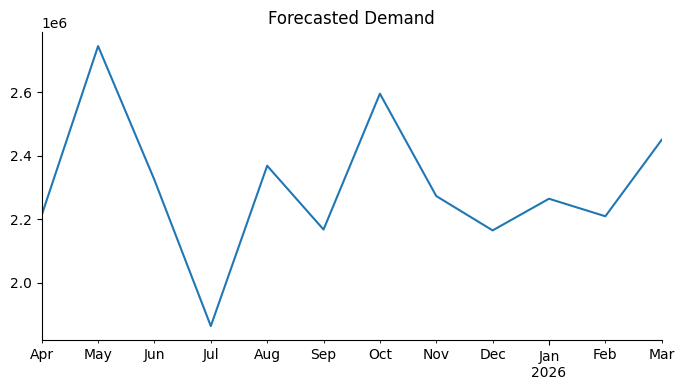

In [ ]:
# @title Forecasted Demand

from matplotlib import pyplot as plt
forecast.plot(kind='line', figsize=(8, 4), title='Forecasted Demand')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:

print("ARIMA Model Evaluation:")
print(f"AIC: {model_fit.aic:.2f}")
print(f"BIC: {model_fit.bic:.2f}")

print("\nSummary of Evaluation Findings:")
print(f"ARIMA Model Fit: AIC={model_fit.aic:.2f}, BIC={model_fit.bic:.2f}. These metrics indicate the relative goodness of fit for the chosen model order (5, 1, 0). Lower values suggest a better fit.")
print("Inventory Model: The current model provides a simplified view based on forecasted demand and a buffer stock. Its practical applicability is limited without incorporating factors like lead time, current inventory, and various costs. A full evaluation would require more detailed historical data and simulation techniques.")

ARIMA Model Evaluation:
AIC: 340.71
BIC: 343.10

Summary of Evaluation Findings:
ARIMA Model Fit: AIC=340.71, BIC=343.10. These metrics indicate the relative goodness of fit for the chosen model order (5, 1, 0). Lower values suggest a better fit.
Inventory Model: The current model provides a simplified view based on forecasted demand and a buffer stock. Its practical applicability is limited without incorporating factors like lead time, current inventory, and various costs. A full evaluation would require more detailed historical data and simulation techniques.


In [ ]:
# Fill missing GSTIN values with a placeholder like 'UNKNOWN'
sales_df['TIN/GSTIN No.'] = sales_df['TIN/GSTIN No.'].fillna('UNKNOWN')
purchase_df['TIN/GSTIN No.'] = purchase_df['TIN/GSTIN No.'].fillna('UNKNOWN')

# Display the updated dataframes with filled GSTIN values
print("Sales Data with filled GSTIN:")
display(sales_df.head())

print("\nPurchase Data with filled GSTIN:")
display(purchase_df.head())

Sales Data with filled GSTIN:


,Vch/Bill No,Account,TIN/GSTIN No.,Type,Total Amount,Sale Amount,Taxable Amt.,IGST,CGST,SGST,Other Amount.
Date,,,,,,,,,,,
2024-04-01,1,HARINI - 5466,UNKNOWN,L/GST-TaxIncl.,2920.0,2497.26,2497.26,0.0,211.37,211.37,0.0
2024-04-01,B-5,.DHANRAJ- 1420,UNKNOWN,L/GST-TaxIncl.,9520.0,9066.64,9066.64,0.0,226.68,226.68,0.0
2024-04-01,F-1,NISHANTH - 5461,UNKNOWN,L/GST-TaxIncl.,27780.0,26302.34,26302.34,0.0,738.83,738.83,0.0
2024-04-01,F-2,RAMESHKUMAR - 9830,UNKNOWN,L/GST-TaxIncl.,23900.0,22761.90,22761.90,0.0,569.05,569.05,0.0
2024-04-01,P-1,ALLIMUTHU - 4255,UNKNOWN,L/GST-TaxIncl.,4388.0,3718.62,3718.62,0.0,334.69,334.69,0.0



Purchase Data with filled GSTIN:


,Vch/Bill No,Account,TIN/GSTIN No.,Type,Total Amount,Purc. Amount,Taxable Amt.,IGST,CGST,SGST,Other Amount.
Date,,,,,,,,,,,
2024-04-01,P/4,A.P.AGRI SOLLUTIONS,33AKMPK0174D1ZI,L/GST-18%,10301.0,8730.00,8730.00,0.0,785.70,785.70,-0.40
2024-04-01,P/8,PREMKRISHNA ASSOCIATES,33BHMPK6821R1ZP,L/GST-18%,27270.0,23109.28,23109.28,0.0,2079.84,2079.84,1.04
2024-04-01,F/0003,EVERGREEN AGRO TRADERS,33AABFE0125H1Z6,L/GST-12%,7504.0,6700.00,6700.00,0.0,402.00,402.00,0.00
2024-04-01,P/0051,SATHYA AGRI INPUTS,33ABLFS6152P1ZK,L/GST-18%,10927.0,9260.22,9260.22,0.0,833.42,833.42,-0.06
2024-04-02,P/35,COVAI IMPEX,33AAJFC9013C1ZX,L/GST-18%,12000.0,10169.52,10169.52,0.0,915.26,915.26,-0.04


In [ ]:
stock_df_raw = pd.read_excel("/content/StockStatus.xlsx", skiprows=4)
display(stock_df_raw.head())

,19:19:19 RCF 1KG,0,Fertilizer,48,Nos,114,5472
0,19:19:19-NPK KATHIR - 25KG,0.0,Fertilizer,5.0,Bag,2690.00,13450.00
1,19-19-19-RICH 25kg,0.0,Fertilizer,15.0,Bag,2597.20,38958.00
2,20-20-0-13-FACTAMFOS - 50kg,0.0,Fertilizer,108.0,Bag,1183.33,127799.97
3,20-20-20 NPK 500ML,0.0,Fertilizer,15.0,Nos,416.00,6240.00
4,20-20-20 NPK 1LIT,0.0,Fertilizer,20.0,Nos,828.00,16560.00


In [ ]:
# Read the entire Excel file to inspect for total row
stock_df_full = pd.read_excel("/content/StockStatus.xlsx", header=None)

# Display the last few rows to check for a total
display(stock_df_full.tail())

total_row = stock_df_full[stock_df_full[2].astype(str).str.contains('Total', na=False)]

if not total_row.empty:
    # Assuming the total amount is in the 7th column (index 6) of that row
    # Convert to numeric, coercing errors
    total_current_stock_amount = pd.to_numeric(total_row.iloc[0, 6], errors='coerce')
    print(f"Extracted Total Current Stock Amount from file footer: {total_current_stock_amount:.2f}")

    # Create a dummy dataframe for plotting with the total value, using the same date index as forecast
    # This is just for visualization purposes to place the total stock on the time axis
    forecast_start_date = forecast.index[0]
    stock_for_plotting = pd.Series(total_current_stock_amount, index=[forecast_start_date])

else:
    print("Could not find a 'Total' row in the stock data.")
    stock_for_plotting = None
    total_current_stock_amount = 0.0

,0,1,2,3,4,5,6
152,ZINC EXTRA - 4 KG,0,Bio Products,36,Bag,115.52,4158.81
153,ZINC SULPHATE - 10 KG,0,Fertilizer,3,Bag,517.86,1553.57
154,ZINC SULPHATE- 5 KG,0,Fertilizer,4,Bag,263.39,1053.57
155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
156,NaN,NaN,Totals,5356,NaN,NaN,1843587.71


Extracted Total Current Stock Amount from file footer: 1843587.71


 Visualization : Actual Monthly Sales vs. Actual Monthly Purchases

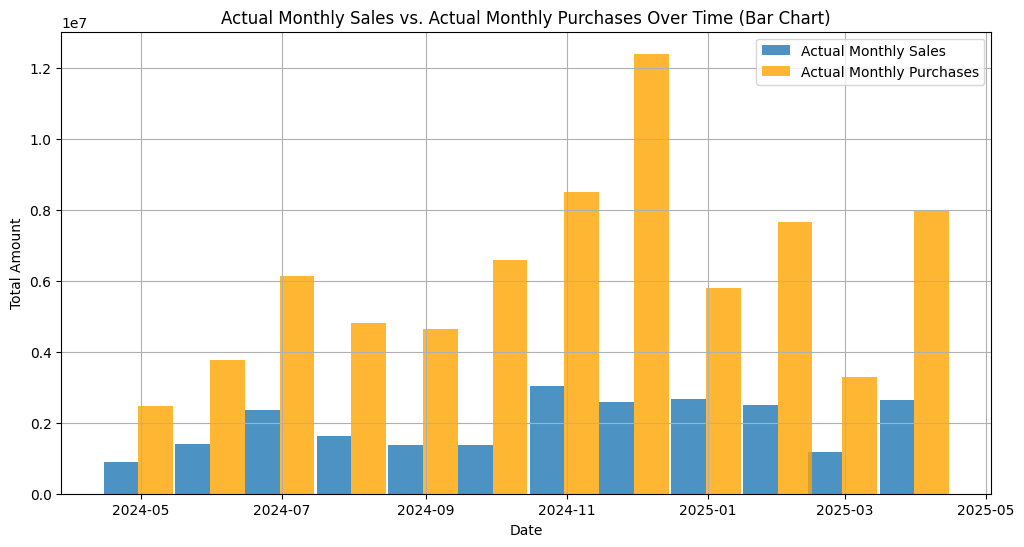

In [ ]:
plt.figure(figsize=(12, 6))
bar_width = 15  # Adjust the width of the bars as needed
plt.bar(df_prepared_monthly.index - pd.Timedelta(days=bar_width/2), df_prepared_monthly['Total Amount_sales'], bar_width, label='Actual Monthly Sales', alpha=0.8)
plt.bar(df_prepared_monthly.index + pd.Timedelta(days=bar_width/2), df_prepared_monthly['Total Amount_purchase'], bar_width, label='Actual Monthly Purchases', color='orange', alpha=0.8)
plt.title('Actual Monthly Sales vs. Actual Monthly Purchases Over Time (Bar Chart)')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.legend()
plt.grid(True)
plt.show()

### Visualization 2: Forecasted Demand vs. Total Current Stock Amount (Bar Chart)

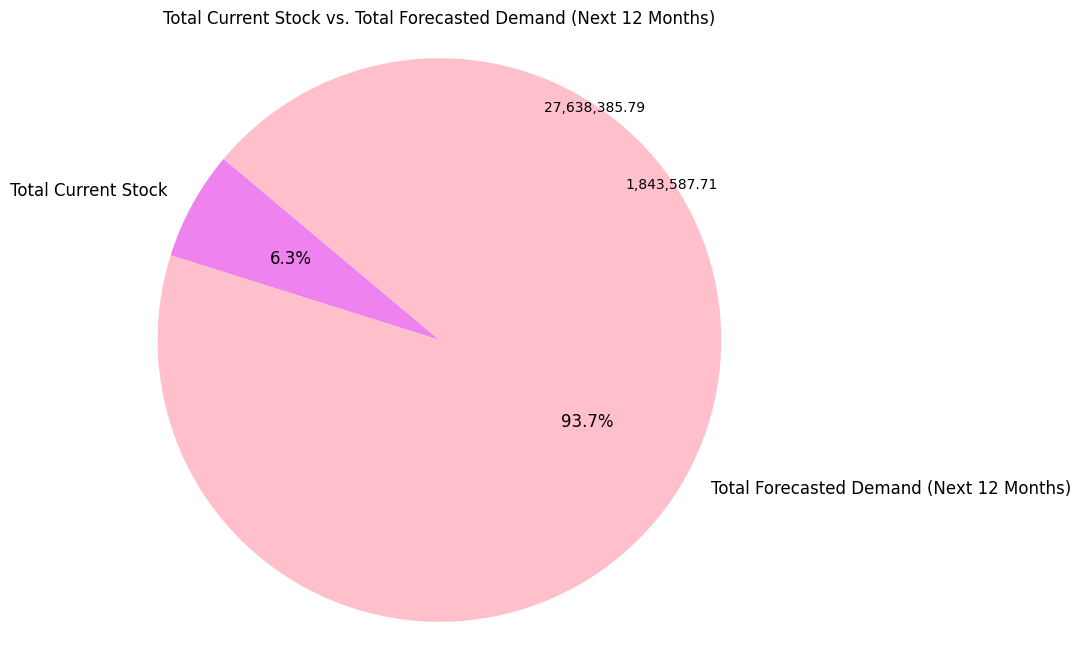

In [ ]:
# Create a pie chart to compare total current stock and total forecasted demand
labels = ['Total Current Stock', 'Total Forecasted Demand (Next 12 Months)']
values = [total_current_stock_amount, forecast.sum()]
colors = ['violet', 'pink']

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
plt.title('Total Current Stock vs. Total Forecasted Demand (Next 12 Months)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Add annotations for specific values
for i, value in enumerate(values):
    plt.text(0.5 * plt.getp(plt.gca(), 'xlim')[1] * (1.5 if i == 0 else 1.0),
             0.5 * plt.getp(plt.gca(), 'ylim')[1] * (1.0 if i == 0 else 1.5),
             f'{value:,.2f}', ha='center', va='center', fontsize=10)


plt.show()

Funnel Graph: Total Purchases vs. Total Sales

Funnel Data:


,Stage,Amount
0,Total Purchases,74094295.11
1,Total Sales,23679103.00


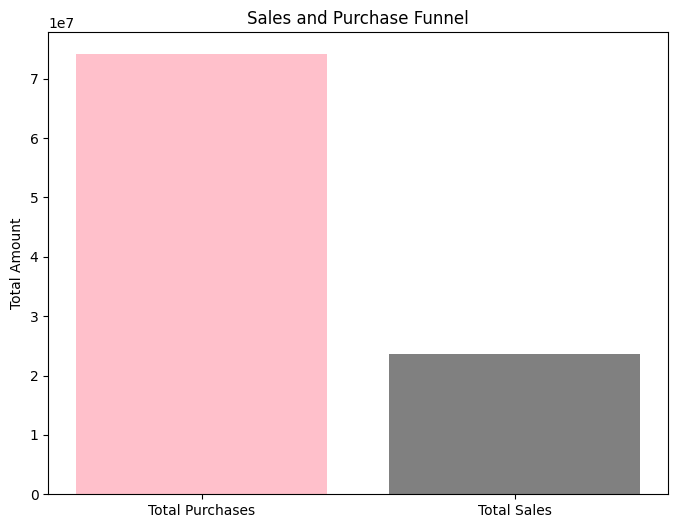

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate total sales and purchases from the monthly aggregated data
# Ensure df_prepared_monthly is available by running the data preparation cells first.
if 'df_prepared_monthly' in locals() or 'df_prepared_monthly' in globals():
    total_sales = df_prepared_monthly['Total Amount_sales'].sum()
    total_purchase = df_prepared_monthly['Total Amount_purchase'].sum()

    # Create a simple dataframe for the funnel chart
    funnel_data = pd.DataFrame({
        'Stage': ['Total Purchases', 'Total Sales'],
        'Amount': [total_purchase, total_sales]
    })

    print("Funnel Data:")
    display(funnel_data)

    # Basic Funnel Chart Visualization (using matplotlib)
    # This is a simplified representation of a funnel

    plt.figure(figsize=(8, 6))
    plt.bar(funnel_data['Stage'], funnel_data['Amount'], color=['pink', 'grey'])
    plt.ylabel('Total Amount')
    plt.title('Sales and Purchase Funnel')
    plt.show()
else:
    print("Error: df_prepared_monthly is not defined. Please ensure the data preparation cells are run.")

In [ ]:
# Get in-sample predictions from the fitted ARIMA model
in_sample_predictions = model_fit.predict(start=sales_data.index.min(), end=sales_data.index.max())

# Calculate the Pearson correlation coefficient between actual sales and in-sample predictions
correlation_in_sample = sales_data.corr(in_sample_predictions)

print(f"Pearson correlation coefficient between Actual Sales and In-Sample Predictions: {correlation_in_sample:.2f}")

Pearson correlation coefficient between Actual Sales and In-Sample Predictions: 0.61


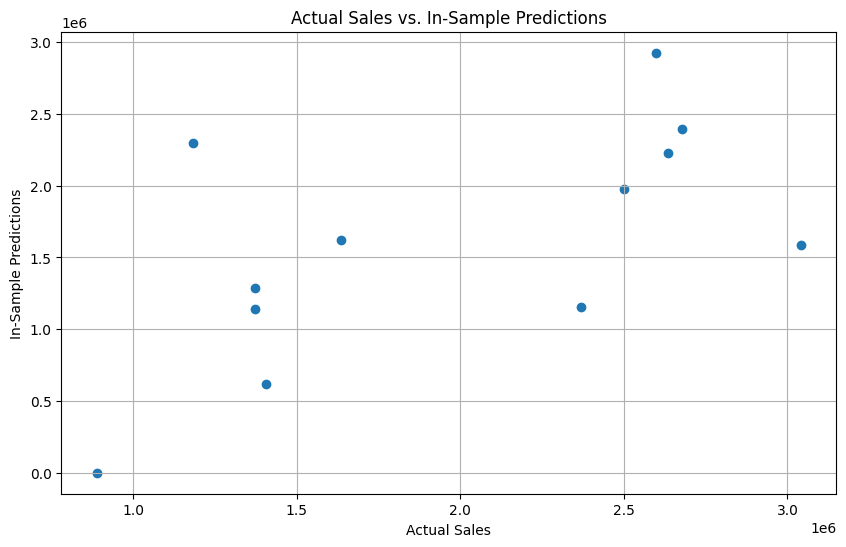

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(sales_data, in_sample_predictions)
plt.title('Actual Sales vs. In-Sample Predictions')
plt.xlabel('Actual Sales')
plt.ylabel('In-Sample Predictions')
plt.grid(True)
plt.show()

In [ ]:
# Create a new dataframe with actual sales and in-sample predictions for the overlapping period
# Since they cover the same period, we can simply combine them
comparison_df_in_sample = pd.DataFrame({
    'Actual Sales': sales_data,
    'In-Sample Predictions': in_sample_predictions
})

# Display the new dataframe
print("DataFrame with Actual Sales and In-Sample Predictions:")
display(comparison_df_in_sample.head())
display(comparison_df_in_sample.tail())

DataFrame with Actual Sales and In-Sample Predictions:


,Actual Sales,In-Sample Predictions
Date,,
2024-04-30,887928.0,0.000000e+00
2024-05-31,1406796.0,6.187605e+05
2024-06-30,2368466.0,1.156628e+06
2024-07-31,1635907.0,1.624635e+06
2024-08-31,1373823.0,1.142137e+06


,Actual Sales,In-Sample Predictions
Date,,
2024-11-30,2596547.0,2.926084e+06
2024-12-31,2676221.0,2.394555e+06
2025-01-31,2500731.0,1.978974e+06
2025-02-28,1182879.0,2.295369e+06
2025-03-31,2634700.0,2.227089e+06


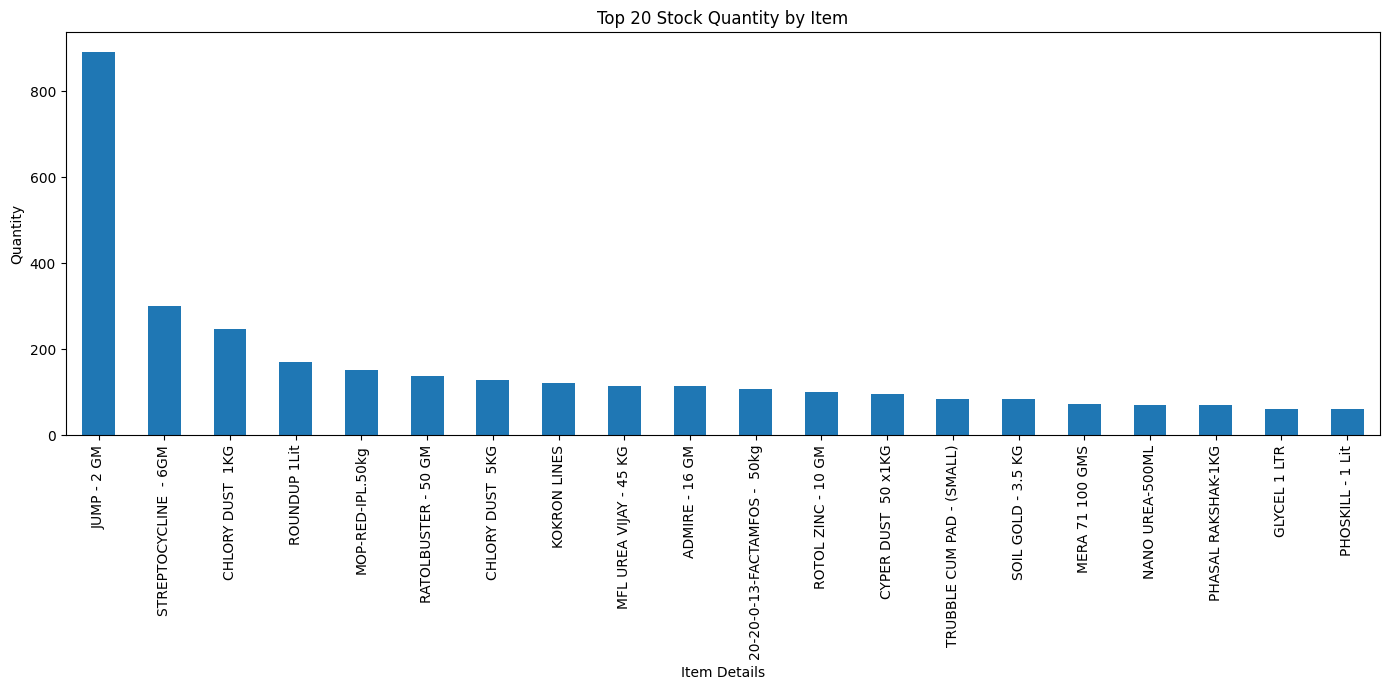

In [ ]:
# Rename columns based on visual inspection of stock_df_full.head()
stock_df_full.columns = ['Item Details', 'MRP', 'Parent Group', 'Qty.', 'Unit', 'Price', 'Amount']

# Remove rows that contain 'Total' or are entirely NaN (like the footer rows)
stock_df_cleaned = stock_df_full[~stock_df_full['Item Details'].astype(str).str.contains('Total', na=False)].dropna(subset=['Item Details', 'Qty.'])

# Convert 'Qty.' to numeric, coercing errors
stock_df_cleaned['Qty.'] = pd.to_numeric(stock_df_cleaned['Qty.'], errors='coerce')
stock_df_cleaned = stock_df_cleaned.dropna(subset=['Qty.'])


# Sort by quantity and select the top N items
top_n = 20
stock_by_item = stock_df_cleaned.groupby('Item Details')['Qty.'].sum().sort_values(ascending=False).head(top_n)

# Create the bar plot
plt.figure(figsize=(14, 7))
stock_by_item.plot(kind='bar')
plt.title(f'Top {top_n} Stock Quantity by Item')
plt.xlabel('Item Details')
plt.ylabel('Quantity')
plt.xticks(rotation=90)
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

In [ ]:
# Load GSTSummary.xlsx with header at row 4 (index 4)
try:
    gst_df = pd.read_excel("GSTSummary 2.xlsx", header=0)

    print("GSTSummary.xlsx loaded successfully with header at row 4.")
    display(gst_df.head())

except FileNotFoundError:
    print("Error: GSTSummary.xlsx not found. Please ensure the file is uploaded.")
except Exception as e:
    print(f"An error occurred while loading GSTSummary.xlsx with header=4: {e}")

GSTSummary.xlsx loaded successfully with header at row 4.


,Details,Taxable Amt.,IGST,CGST,SGST,Total Tax
0,Input GST,14746779.06,0,676433.46,676433.46,1352866.92
1,@ 5 % (Local),9442919.82,0,236073.13,236073.13,472146.26
2,@ 12 % (Local),701958.95,0,42117.53,42117.53,84235.06
3,@ 18 % (Local),4600600.29,0,398242.8,398242.8,796485.6
4,Exempt (Local),1300,0,0,0,0


### Visualization: Distribution of Total Tax Amount (KDE Plot)

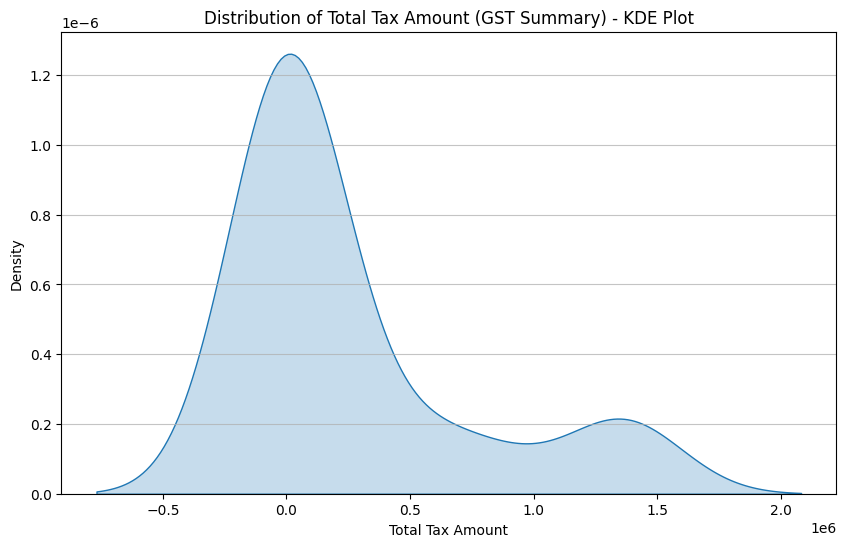

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

if not gst_df.empty:
    # Select the last column by index
    total_tax_column = gst_df.iloc[:, -1]

    # Convert the column to numeric, coercing errors
    total_tax_gst = pd.to_numeric(total_tax_column, errors='coerce')

    # Drop any NaN values that resulted from coercion
    total_tax_gst = total_tax_gst.dropna()

    if not total_tax_gst.empty:
        # Generate a Kernel Density Estimate (KDE) plot for a smoother representation of distribution
        plt.figure(figsize=(10, 6))
        sns.kdeplot(total_tax_gst, fill=True) # Use seaborn for a KDE plot
        plt.title('Distribution of Total Tax Amount (GST Summary) - KDE Plot')
        plt.xlabel('Total Tax Amount')
        plt.ylabel('Density')
        plt.grid(axis='y', alpha=0.75)
        plt.show()
    else:
        print("The identified 'Total Tax' column is empty or contains no valid numeric data after cleaning.")
else:
    print("The gst_df DataFrame is empty. Please ensure the GSTSummary.xlsx file is loaded correctly.")

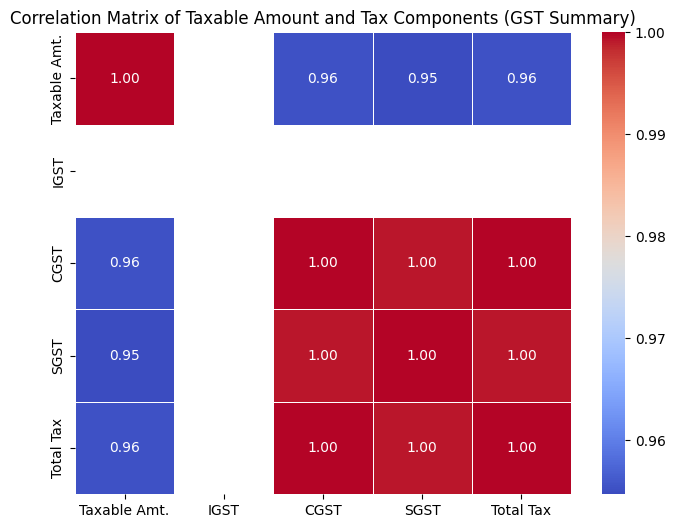

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Select the relevant numeric columns from gst_df
# Ensure columns exist and are numeric
numeric_gst_cols = ['Taxable Amt.', 'IGST', 'CGST', 'SGST', 'Total Tax']

# Check if all required columns exist in gst_df before proceeding
if all(col in gst_df.columns for col in numeric_gst_cols):
    gst_numeric_df = gst_df[numeric_gst_cols].apply(pd.to_numeric, errors='coerce').dropna()

    if not gst_numeric_df.empty:
        # Calculate the correlation matrix
        correlation_matrix = gst_numeric_df.corr()

        # Generate a heatmap of the correlation matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('Correlation Matrix of Taxable Amount and Tax Components (GST Summary)')
        plt.show()
    else:
        print("Could not create a numeric DataFrame from the selected GST columns after dropping NaNs.")
else:
    print("The expected columns for the correlation heatmap were not found in the gst_df DataFrame.")

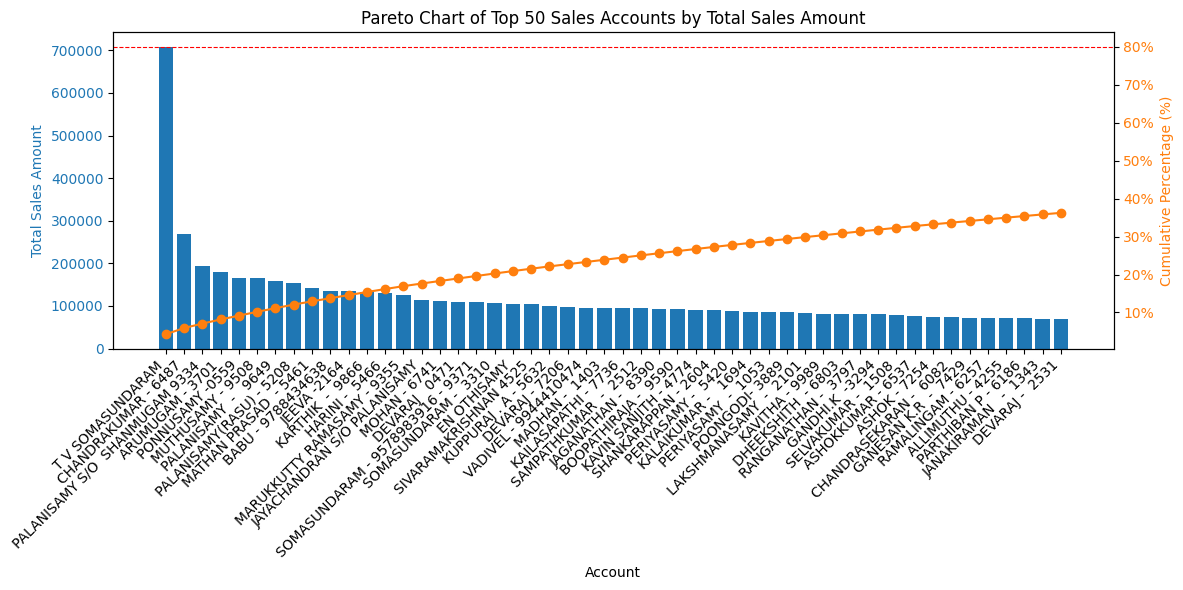

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# Ensure 'Total Amount' and 'Account' columns are available and clean
sales_df['Total Amount'] = pd.to_numeric(sales_df['Total Amount'], errors='coerce')
sales_df_cleaned = sales_df.dropna(subset=['Total Amount', 'Account'])

# Calculate total sales by account
sales_by_account = sales_df_cleaned.groupby('Account')['Total Amount'].sum().sort_values(ascending=False)

# Select only the top 5 accounts
top_n = 50
sales_by_account_top_n = sales_by_account.head(top_n)

# Calculate cumulative percentage for the top N accounts
sales_by_account_cumulative_top_n = sales_by_account_top_n.cumsum() / sales_by_account.sum() * 100


# Create the Pareto chart for the top N accounts
fig, ax1 = plt.subplots(figsize=(12, 6)) # Adjusted figure size for fewer bars

# Bar chart for individual account sales (top N)
ax1.bar(sales_by_account_top_n.index, sales_by_account_top_n.values, color='C0')
ax1.set_xlabel('Account')
ax1.set_ylabel('Total Sales Amount', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.set_title(f'Pareto Chart of Top {top_n} Sales Accounts by Total Sales Amount')
plt.xticks(rotation=45, ha='right') # Adjusted rotation for fewer labels

# Line chart for cumulative percentage (top N)
ax2 = ax1.twinx()
ax2.plot(sales_by_account_top_n.index, sales_by_account_cumulative_top_n, color='C1', marker='o', linestyle='-')
ax2.set_ylabel('Cumulative Percentage (%)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax2.yaxis.set_major_formatter(PercentFormatter())

# Optional: Add a line at 80% to highlight the 80/20 rule
# Note: The 80% line might not be relevant if the top 5 accounts don't reach 80%
ax2.axhline(80, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout() # Adjust layout
plt.show()

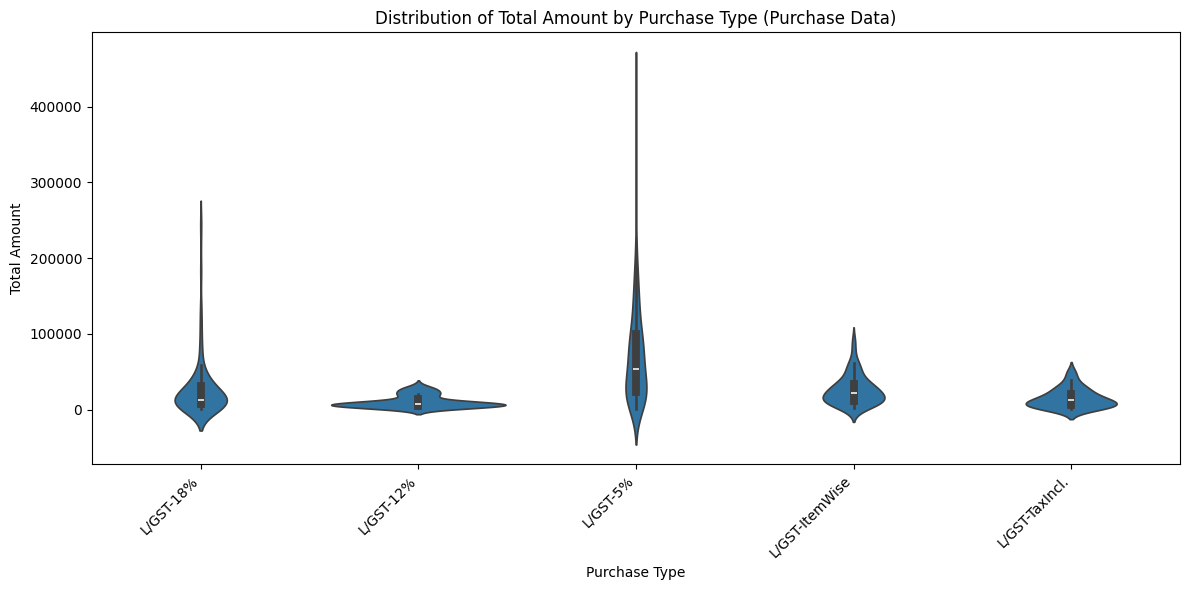

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Total Amount' and 'Type' columns are available and clean in purchase_df
purchase_df['Total Amount'] = pd.to_numeric(purchase_df['Total Amount'], errors='coerce')
purchase_df_cleaned = purchase_df.dropna(subset=['Total Amount', 'Type'])

if not purchase_df_cleaned.empty:
    # Generate the violin plot for Purchase Data
    plt.figure(figsize=(12, 6))
    sns.violinplot(x='Type', y='Total Amount', data=purchase_df_cleaned)
    plt.title('Distribution of Total Amount by Purchase Type (Purchase Data)')
    plt.xlabel('Purchase Type')
    plt.ylabel('Total Amount')
    plt.xticks(rotation=45, ha='right') # Rotate labels for readability
    plt.tight_layout() # Adjust layout
    plt.show()
else:
    print("The purchase data is empty or missing 'Total Amount' or 'Type' columns after cleaning.")